# Homework Assignment 2 (40 points)

# Submission Rules

#### 제출기한: **2026년 4월 12일 (일) 23:00까지** (제출 기한 엄수)
- 제출방법 고려대학교 LMS (lms.korea.ac.kr) 과목 > 주차학습 > 과제 및 평가

#### 제목형식
- 보고서 파일: DAS509_hw2_이름.pdf (파일형식은 **반드시 pdf**)
- 코드 파일: DAS509_hw2_이름.ipynb (jupyter notebook이 아닌 경우 다른 확장자 가능)

## 문제1 - 데이터 시각화 (10점)

이 문제에서는 `Pandas`와 `Matplotlib`을 이용하여 `Company Sales` 데이터를 시각화한다. 먼저 다음의 모듈과 데이터를 업로드하자. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 업로드
sales_data = pd.read_csv("./data/company_sales_data.csv")
sales_data.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


(a) 월별 총수익(total profit)을 계산하고 다음과 같은 그림을 생성하라. x축과 y축의 레이블은 각각 `Month Number`와 `Sold Unit Number`로 지정하라. 생성된 그림은 다음과 유사하도록 하라. (5점)

![](img/fig1.PNG)

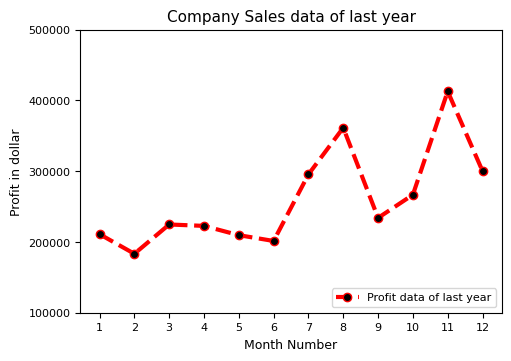

In [2]:
#sales_data.info() 
plt.figure(figsize = (5,3.5), layout='constrained')
plt.plot(
    sales_data['month_number'],
    sales_data['total_profit'],
    color = 'red',
    linestyle = '--',
    marker = 'o',
    markerfacecolor = 'black',
    linewidth=3 ,
    label = 'Profit data of last year' 
)

plt.title('Company Sales data of last year', fontsize = 11)
plt.xlabel('Month Number', fontsize = 9) 
plt.ylabel('Profit in dollar', fontsize = 9)
plt.xticks(sales_data['month_number'], fontsize=8)
plt.ylim(100000,500000)
plt.yticks(range(100000, 600000, 100000), fontsize=8)  
plt.legend(loc = 'lower right', fontsize=8) #범례
plt.show()

(b) 다음과 같이 각 상품별 월별 판매량을 멀티라인 플롯을 이용하여 시각화하라. 생성된 그림은 다음과 같아야 한다. (5점)

![](img/fig2.PNG)

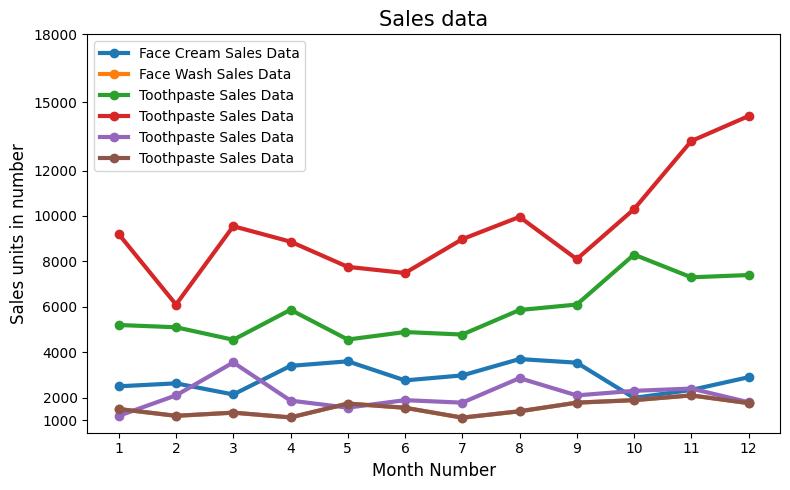

In [3]:
products = list(sales_data.columns[1:7])
labels = ['Face Cream Sales Data',
          'Face Wash Sales Data', 
          'Toothpaste Sales Data', 
          'Toothpaste Sales Data',
          'Toothpaste Sales Data',
          'Toothpaste Sales Data']

plt.figure(figsize =(8,5))
for product, label in zip(products, labels): # 개별적인 범례 제작을 위해 
    plt.plot(
        sales_data['month_number'],
        sales_data[product], 
        marker = 'o',
        linewidth=3,
        label = label
    )

plt.title('Sales data', fontsize = 15)
plt.xlabel('Month Number', fontsize = 12)
plt.ylabel('Sales units in number', fontsize = 12)
plt.xticks(sales_data['month_number'], fontsize=10)
plt.yticks([1000, 2000, 4000, 6000, 8000, 10000, 12000, 15000, 18000], fontsize=10)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

(c) `Face cream`과 `Face Wash`의 월별 총 상품 판매량을 다음과 같이 막대 그래프를 이용하여 그려라. (5점)

![](img/fig3.PNG)

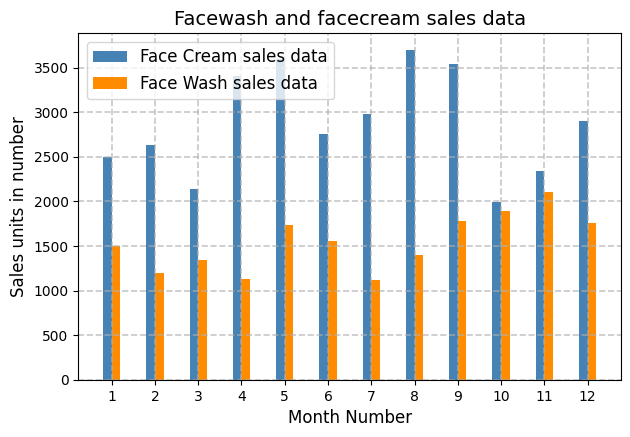

In [4]:
x  = sales_data['month_number']
width = 0.2

fig, ax = plt.subplots(figsize = (7,4.5))
ax.bar(x - width/2, sales_data['facecream'], width = width, label = 'Face Cream sales data' , color = 'steelblue')
ax.bar(x + width/2, sales_data['facewash'], width = width, label = 'Face Wash sales data' , color = 'darkorange')

ax.set_title('Facewash and facecream sales data', fontsize = 14)
ax.set_xlabel('Month Number', fontsize = 12)
ax.set_ylabel('Sales units in number', fontsize = 12)
ax.set_xticks(x)
ax.legend(loc = 'upper left', fontsize = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.7, linewidth = 1.2)
ax.grid(axis = 'x', linestyle = '--', alpha = 0.7, linewidth = 1.2)
plt.show()

(d) `Bathing Soap`의 월별 총 상품 판매량을 다음과 같이 막대 그래프를 이용하여 그려라. (5점)

![](img/fig4.png)

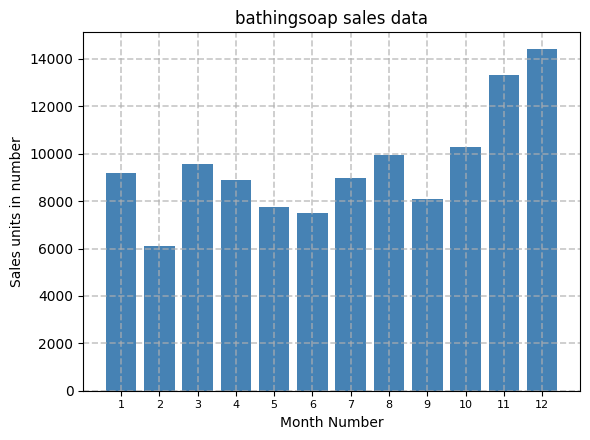

In [5]:
plt.figure(figsize = (6,4.5))
plt.bar(
    sales_data['month_number'],
    sales_data['bathingsoap'],
    color = 'steelblue'
)
plt.title('bathingsoap sales data', fontsize = 12)
plt.xlabel('Month Number', fontsize = 10)
plt.ylabel('Sales units in number', fontsize = 10)
plt.xticks(sales_data['month_number'], fontsize=8)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7, linewidth = 1.2)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7, linewidth = 1.2)
plt.tight_layout()
plt.show()

## 문제2 - China Investment 2019 데이터 분석 (15점)

다음 [**링크**](https://www.aei.org/china-global-investment-tracker) 혹은 수업 온라인 폴더에서 **"China-Global-Investment-Tracker-2019-Spring-FINAL.xlsx"** 데이터를 다운로드하자. 이 데이터는 중국 기업과 정부 기관이 중국 외 지역에 투자한 정보를 포함하는 엑셀 파일이다. Pandas를 사용하여 이 데이터를 업로드하고, 다음과 같이 데이터 분석을 수행하라.



### **1. 데이터 불러오기 및 전처리**

`pandas`를 사용하여 엑셀 파일을 읽어오고, 컬럼명을 변환한 후 데이터의 구조를 확인하라.

In [6]:
import pandas as pd
import numpy as np

# 엑셀 파일 로드 (헤더에서 5줄을 스킵)
data = pd.read_excel("./data/China-Global-Investment-Tracker-2019-Spring-FINAL.xlsx", skiprows=5)

# 컬럼명 변환 (공백을 밑줄로 바꾸고 소문자로 변경)
data.columns = data.columns.str.replace(" ", "_").str.lower()
data = data.rename(columns = {"quantity_in_millions":"investment"})

# 데이터 구조 확인
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               1571 non-null   int64  
 1   month              1571 non-null   object 
 2   investor           1571 non-null   object 
 3   investment         1571 non-null   int64  
 4   share_size         1026 non-null   object 
 5   transaction_party  1109 non-null   object 
 6   sector             1571 non-null   object 
 7   subsector          1067 non-null   object 
 8   country            1571 non-null   object 
 9   region             1571 non-null   object 
 10  bri                1029 non-null   float64
 11  greenfield         478 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 147.4+ KB
None
   year     month                   investor  investment share_size  \
0  2005   January                  Minmetals         500        NaN   
1  2005   

  ### **2. 데이터 분석 문제**
  
  (a) `groupby`를 사용하여 각 국가가 하나의 지역(region)에만 속하는 것을 확인하라. 만일 한 국가(country)가 여러 개의 지역(region)에 속하는 경우가 있으면 출력하라. (10점)

In [7]:
country_region = data.groupby('country')['region'].nunique()
multi_region = country_region[country_region > 1]


if multi_region.empty:
    print("모든 국가가 하나의 지역에 속해 있습니다.")
else:
    print(f"여러 지역에 속한 국가 수 : {len(multi_region)}")
    print(multi_region)
    
    # 실제 지역(region) 확인
    for country in multi_region.index:
        regions = data[data['country'] == country]['region'].unique()
        print(f"[상세] {country}  : {', '.join(regions)}")


여러 지역에 속한 국가 수 : 1
country
Indonesia    2
Name: region, dtype: int64
[상세] Indonesia  : East Asia, West Asia


(b) 각 지역(region)별 총 투자액 중에서 각 산업(sector)이 차지하는 비율을 계산하고 표로 정리하라. `pivot_table`을 사용하여 지역(region)을 열(columns)로, 산업(sector)을 행(rows)으로 설정한 후, 총 투자액 대비 각 산업이 차지하는 비율을 계산하라. 비율이 너무 길어지지 않도록 반올림하고, 가장 많은 투자를 받은 산업을 확인하라. (10점)

In [8]:
pivot = data.pivot_table(index='sector',
                         columns = 'region',
                         values = 'investment', 
                         aggfunc='sum')

#b-1. 각 지역(region)별 투자금액의 총합을 계산하여 전체 투자금액에서 차지하는 비율을 계산하고 표로 정리하라
pivot_pct = (pivot.div(pivot.sum(axis=0), axis=1) * 100).round(2)
print(f" [b-1] 각 지역별 투자금액 비율:\n{pivot_pct}")

#b-2. 각 지역(region)별로 가장 많은 투자를 받은 산업
most_invested_sector_by_region = pivot.idxmax()
#b-2-1. 전체 기준 가장 많은 투자를 받은 산업
most_invested_sector = pivot.sum(axis=1).idxmax()

print(f" [b-2] 각 지역별로 가장 많은 투자를 받은 산업: {most_invested_sector_by_region}")
print(f" [b-2-1] 전체 기준 가장 많은 투자를 받은 산업: {most_invested_sector}")

 [b-1] 각 지역별 투자금액 비율:
region         Arab Middle East and North Africa  Australia  East Asia  \
sector                                                                   
Agriculture                                  NaN       2.96       2.38   
Chemicals                                   1.33       0.19       0.08   
Energy                                     80.91      36.63      30.38   
Entertainment                                NaN       1.08       1.73   
Finance                                      NaN       2.01       3.46   
Health                                       NaN       6.42       0.17   
Logistics                                   0.40        NaN       8.90   
Metals                                      5.69      34.04      11.23   
Other                                       3.96        NaN       7.20   
Real estate                                 2.07      10.32      13.04   
Technology                                   NaN       0.13       4.57   
Tourism         

(c) 각 산업(sector)별 투자 금액의 평균(mean) 및 표준편차(std)를 계산하라. 로그 변환한 후 투자 금액의 평균 및 표준편차도 다시 계산한 후 비교하라. 평균과 표준편차의 관계를 설명하고, 예외적인 산업을 분석하라. (10점)

In [9]:
# 각 산업별 투자 금액의 평균 및 표준편차 계산
stats_original = data.groupby('sector')['investment'].agg(['mean', 'std'])
stats_original.columns = ['mean_original', 'std_original']

# 로그 변환 
len(data) == sum(data['investment'] > 0) # 로그 변환을 위해 투자 금액이 양수인 데이터 확인
data_for_log = data.copy() 
data_for_log['investment_log'] = np.log(data_for_log['investment']) 

stats_log = data_for_log.groupby('sector')['investment_log'].agg(['mean', 'std'])
stats_log.columns = ['mean_log', 'std_log']

# 원본과 로그 변환된 데이터의 통계량을 결합하여 CV(변동계수) 계산
stats_combined = stats_original.join(stats_log, how='inner')
stats_combined['cv_original'] = stats_combined['std_original'] / stats_combined['mean_original']
stats_combined['cv_log'] = stats_combined['std_log'] / stats_combined['mean_log']

print(stats_combined.to_string())

# 평균과 표준편차의 관계 설명
corr_orig = stats_combined['mean_original'].corr(stats_combined['std_original'])
corr_log = stats_combined['mean_log'].corr(stats_combined['std_log'])

print(f"""
[평균과 표준편차의 관계]
- 원본: 평균이 클수록 표준편차도 큰 규모 의존성이 존재 (상관계수: {corr_orig:.4f})
- 로그 변환 후: 규모 의존성이 완화되어 산업 간 변동성 비교가 용이 (상관계수: {corr_log:.4f})
- 즉 로그 변환은 투자금액 분포의 왜도(skewness)를 줄여 정규분포에 가깝게 만듦
""")

# 예외적인 산업 식별
# 기준: 로그 변환 후 CV가 평균 + 1표준편차 초과 (상위 약 16%)
threshold = stats_combined['std_log'].mean() + stats_combined['std_log'].std()
exceptional = stats_combined[stats_combined['std_log'] > threshold]
print(f""" 
[예외적인 산업] 
- 기준 : std_log 기준 mean + 1σ (정규분포 가정 시 상위 약 16%)
- std_log > {threshold:.4f}) : {len(exceptional)}개\n""") 
print(exceptional[['mean_original', 'std_original', 'cv_original', 'cv_log']])
print(f"\n→ {', '.join(exceptional.index)} 산업은 로그 변환 후에도 변동성이 높아, 소수의 대규모 투자 또는 구조적으로 불균일한 투자 패턴이 존재함을 의미")


               mean_original  std_original  mean_log   std_log  cv_original    cv_log
sector                                                                               
Agriculture      1206.617647   5238.126192  5.886343  1.092799     4.341165  0.185650
Chemicals         734.117647    664.915961  6.138781  1.036458     0.905735  0.168838
Energy           1000.000000   1376.055439  6.267939  1.128986     1.376055  0.180121
Entertainment     785.245902   1413.609572  5.900528  1.111358     1.800213  0.188349
Finance           838.333333   1335.532747  6.016699  1.139753     1.593081  0.189432
Health            392.592593    382.100378  5.639745  0.776388     0.973275  0.137664
Logistics        1322.800000   3165.772049  5.954763  1.301176     2.393236  0.218510
Metals            761.075269   1215.396687  6.052103  1.026628     1.596947  0.169632
Other             359.166667    566.938681  5.483358  0.759664     1.578484  0.138540
Real estate       451.928251    458.027847  5.755159  

(d) 연도(year)별 각 산업(sector)의 총 투자액을 표로 정리하라. 연도별 산업 투자 총액을 정리하고, 특정 기간(2005-2012 vs. 2013-2015) 동안 투자 증가율이 가장 높았던 산업을 분석하라. (10점)

In [10]:
#연도별 각 산업의 총 투자금액 정리
year_sector = data.pivot_table(
    index='year',
    columns='sector',
    values='investment',
    aggfunc='sum',
    fill_value = 0    
)
print(f"[연도별 각 산업 총 투자액]\n {year_sector.to_string()}")

#연도별 산업 투자 총액 정리
year_total = year_sector.sum(axis=1)
print(f"\n [연도별 산업 투자 총액]\n {year_total.to_string()}")   

#기간별 총 투자액 비교
early_period = year_sector.loc[year_sector.index <=2012].sum()
late_period = year_sector.loc[(year_sector.index >= 2013) & (year_sector.index <= 2015)].sum()
growth_rate = ((late_period - early_period) / early_period.replace(0, np.nan) * 100).round(2)


comparison = pd.DataFrame({ '2012년 이전 총액' : early_period,
                           '2013-2015년 총액' : late_period, 
                           '성장률(%)' : growth_rate}).sort_values(by = '성장률(%)', ascending=False)

top_growth = comparison['성장률(%)'].idxmax()
print(f"\n 투자 증가율이 가장 높았던 산업 : {top_growth} (성장률: {comparison.loc[top_growth, '성장률(%)']}%)")


[연도별 각 산업 총 투자액]
 sector  Agriculture  Chemicals  Energy  Entertainment  Finance  Health  Logistics  Metals  Other  Real estate  Technology  Tourism  Transport  Utilities
year                                                                                                                                                    
2005              0        180    6360              0        0       0          0    1860      0            0        1740        0        100          0
2006            480          0    9970              0      100       0          0    7310    120         1300           0        0        970          0
2007              0        700    2610              0    19370       0        150    6280    120          150         460        0        270          0
2008            340          0   22100              0     4650     360          0   22220      0          390           0      110       6120          0
2009            370          0   34480              0     3100  

## 문제3 - NYC Flights 13 데이터 (15점)

`nycflights13` 데이터(https://www.kaggle.com/datasets/aephidayatuloh/nyc-flights-2013)의 **flights**, **planes**, **weather** 데이터를 사용하여 다음 질문들에 답하라. 해당 데이터는 과제 data 폴더에서도 확인가능하다. 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
flights = pd.read_csv("./data/flights.csv")  # flights 데이터
planes = pd.read_csv("./data/planes.csv")  # planes 데이터
weather = pd.read_csv("./data/weather.csv")  # weather 데이터

# 데이터 확인
print(flights.head())
print(planes.head())
print(weather.head())

   Unnamed: 0  year  month  day  dep_time  sched_dep_time  dep_delay  \
0           1  2013      1    1     517.0             515        2.0   
1           2  2013      1    1     533.0             529        4.0   
2           3  2013      1    1     542.0             540        2.0   
3           4  2013      1    1     544.0             545       -1.0   
4           5  2013      1    1     554.0             600       -6.0   

   arr_time  sched_arr_time  arr_delay carrier  flight tailnum origin dest  \
0     830.0             819       11.0      UA    1545  N14228    EWR  IAH   
1     850.0             830       20.0      UA    1714  N24211    LGA  IAH   
2     923.0             850       33.0      AA    1141  N619AA    JFK  MIA   
3    1004.0            1022      -18.0      B6     725  N804JB    JFK  BQN   
4     812.0             837      -25.0      DL     461  N668DN    LGA  ATL   

   air_time  distance  hour  minute            time_hour  
0     227.0      1400     5      15  20

(a) 취소된 항공편 비율이 가장 높은 달과 가장 낮은 달을 확인하라. 월별로 취소된 항공편 비율을 계산하고, 계절적인 패턴이 있는지 분석하라. (6점)

 [월별 항공편 취소율]
       total_flights  canceled_flights  cancel_rate(%)
month                                                 
1              27004               521            1.93
2              24951              1261            5.05
3              28834               861            2.99
4              28330               668            2.36
5              28796               563            1.96
6              28243              1009            3.57
7              29425               940            3.19
8              29327               486            1.66
9              27574               452            1.64
10             28889               236            0.82
11             27268               233            0.85
12             28135              1025            3.64

 [취소율이 가장 높은 월] : 2월 (취소율: 5.05%)
 [취소율이 가장 낮은 월] : 10월 (취소율: 0.82%)

[계절적 패턴 분석]

[계절별 항공편 취소율]
        total_flights  canceled_flights  cancel_rate(%)
season                                                 
Winter

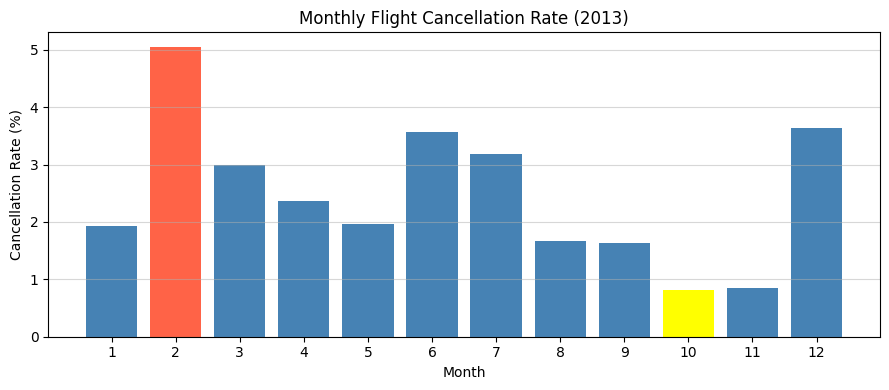

In [12]:
# 취소된 항공편 : dep_time이 결측치인 경우 canceled가 1, 그렇지 않은 경우 0으로 표시
flights['canceled'] = flights['dep_time'].isna().astype(int)    

monthly_cancel = flights.groupby('month').agg(
                total_flights = ('canceled', 'count'),  # 신규컬럼명 = (기존컬럼명, 집계함수)  
                canceled_flights = ('canceled', 'sum')
            )
monthly_cancel['cancel_rate(%)'] = (monthly_cancel['canceled_flights'] / monthly_cancel['total_flights'] * 100).round(2)

print(f" [월별 항공편 취소율]\n{monthly_cancel.to_string()}")

# 취소된 항공편 비율이 가장 높은 달과 가장 낮은 달 
max_month = monthly_cancel['cancel_rate(%)'].idxmax()
min_month = monthly_cancel['cancel_rate(%)'].idxmin()
print(f"\n [취소율이 가장 높은 월] : {max_month}월 (취소율: {monthly_cancel.loc[max_month, 'cancel_rate(%)']}%)")
print(f" [취소율이 가장 낮은 월] : {min_month}월 (취소율: {monthly_cancel.loc[min_month, 'cancel_rate(%)']}%)")

# 계절적 패턴 분석 

# 12-2월: 겨울, 3-5월: 봄, 6-8월: 여름, 9-11월: 가을
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'   
flights['season'] = flights['month'].apply(assign_season)
seasonal_cancel = flights.groupby('season').agg(
    total_flights = ('canceled', 'count'),
    canceled_flights = ('canceled', 'sum')      ).reindex(season_order)  # 계절 순서대로 정렬
seasonal_cancel['cancel_rate(%)'] = (seasonal_cancel['canceled_flights'] / seasonal_cancel['total_flights'] * 100).round(2)

print("\n[계절적 패턴 분석]")
print(f"\n[계절별 항공편 취소율]\n{seasonal_cancel.to_string()}")
print("겨울(12~2월, 눈보라·블리자드)과 여름(6~8월, 허리케인 시즌·뇌우)에 취소율이 높은 경향이 나타납니다.")
print("반면 가을(9~11월)은 비교적 취소율이 낮습니다.")


# 시각화
plt.figure(figsize=(9, 4))
colors = ['tomato' if i == max_month 
                 else 'yellow' if i == min_month 
                 else 'steelblue' 
                  for i in monthly_cancel.index]
plt.bar(monthly_cancel.index, monthly_cancel['cancel_rate(%)'], color=colors)
plt.title('Monthly Flight Cancellation Rate (2013)')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


(b) 2013년 NYC 공항에서 가장 많이 운항한 항공기를 확인하고, 주별 운항 횟수를 시각화하라. `tailnum` 기준으로 운항 횟수를 계산하고, 주별 운항 횟수를 그래프로 나타내라. (6점)

최다 운항 항공기: N725MQ (운항 횟수: 575회)


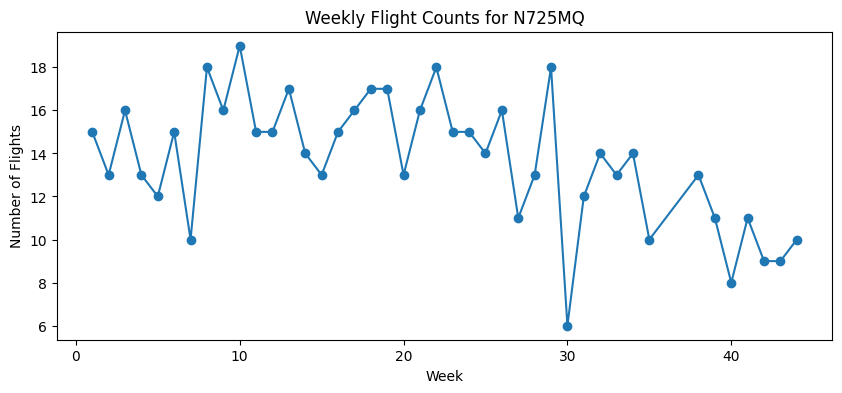

In [13]:
# 2013년에 가장 많이 운항된 항공기
top_plane = flights['tailnum'].value_counts()
print(f"최다 운항 항공기: {top_plane.idxmax()} (운항 횟수: {top_plane.max()}회)")

# 해당 항공기의 주별 운항 횟수
top_tailnum_flights = flights[ flights['tailnum'] == top_plane.idxmax() ].copy()
top_tailnum_flights['date'] = pd.to_datetime(top_tailnum_flights['time_hour'])
top_tailnum_flights['week'] = top_tailnum_flights['date'].dt.isocalendar().week.astype(int)
weekly_flights = top_tailnum_flights.groupby('week').size()  # 취소편 포함을 위해 size() 사용

plt.figure(figsize = (10, 4))
plt.plot(weekly_flights.index, weekly_flights.values, marker='o')
plt.xlabel('Week')
plt.ylabel('Number of Flights')
plt.title(f'Weekly Flight Counts for {top_plane.idxmax()}')
plt.show()

(c) 2013년 뉴욕 공항에서 운항한 항공기 중 가장 오래된 항공기는 무엇인가? (항공기는 `tailnum` 변수로 식별됨) 또한, 2013년 뉴욕 공항에서 운항한 항공기 중 `planes` 테이블에 포함된 항공기의 개수는 몇 대인가? (7점)

In [14]:
# 2013년에 운항한 항공기 중 가장 오래된 항공기 
flight_talinums = flights['tailnum'].dropna().unique()
plane_in_use = planes[planes['tailnum'].isin(flight_talinums)].copy()
oldest_plane = plane_in_use.loc[plane_in_use['year'].idxmin()]

print(f"2013년에 운항한 항공기 중 가장 오래된 항공기:  {oldest_plane['tailnum']} (제조연도: {int(oldest_plane['year'])}년)")

#2013년에 운항한 항공기 중 planes 테이블에 포함된 항공기 수
print(f"2013년에 운항한 항공기 중 planes 테이블에 포함된 항공기 수: {plane_in_use.shape[0]}대")


2013년에 운항한 항공기 중 가장 오래된 항공기:  N381AA (제조연도: 1956년)
2013년에 운항한 항공기 중 planes 테이블에 포함된 항공기 수: 3322대


(d) 제조사(manufacturer) 정보가 없는 항공기의 개수를 구하라. 가장 흔한 5개의 제조사를 확인하라. 2013년 뉴욕에서 운항한 항공기의 제조사 분포가 시간이 지남에 따라 어떻게 변했는지 분석하라. (제조사 이름을 정리하고, 희귀 제조사는 "Other" 카테고리로 통합할 필요가 있을 수 있음.) (7점)


 제조사 정보 없는 항공기 수 : 722
 [가장 흔한 5개 제조사] 
manufacturer
BOEING              1630
AIRBUS INDUSTRIE     400
BOMBARDIER INC       368
AIRBUS               336
EMBRAER              299

[분석] BOEING과 AIRBUS는 꾸준히 높은 비중을 차지하며, 2000년대 이후 제조된 항공기에서 EMBRAER의 비중이 증가하는 추세를 보입니다.


<Figure size 1200x300 with 0 Axes>

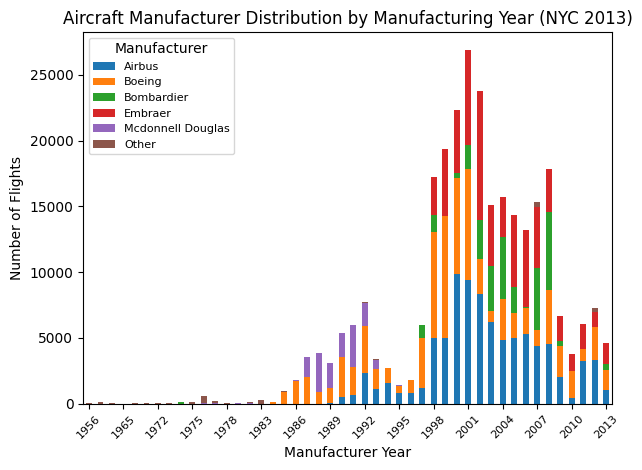

In [15]:
flights_planes = flights.merge(planes[['tailnum', 'year','manufacturer']],
                               on='tailnum', how='left', suffixes=('', '_plane'))

# 항공기 기준으로 중복 제거 (같은 tailnum은 한 번만 카운트)
unique_planes = flights_planes.drop_duplicates(subset='tailnum')

# 제조사 정보가 없는 항공기
print(f" 제조사 정보 없는 항공기 수 : {unique_planes['manufacturer'].isnull().sum()}")

# 가장 흔한 5개 제조사
top_manufacturers = unique_planes['manufacturer'].value_counts().head(5)
print(f" [가장 흔한 5개 제조사] \n{top_manufacturers.to_string()}")

# 제조사 이름 정리
def clean_manufacturer(name):
    if pd.isna(name):
        return 'Unknown'
    name = name.upper().strip()
    if 'BOEING' in name:
        return 'Boeing'
    elif 'AIRBUS' in name:
        return 'Airbus'
    elif 'EMBRAER' in name:
        return 'Embraer'
    elif 'BOMBARDIER' in name or 'CANADAIR' in name:
        return 'Bombardier'
    elif 'MCDONNELL' in name:
        return 'Mcdonnell Douglas'
    else:
        return 'Other'

flights_planes['manufacturer_grouped'] = flights_planes['manufacturer'].apply(clean_manufacturer)

# 시간에 따른 분포 (항공편 기준 — 운항 트렌드 분석이므로 중복 제거 안 함)
year_mfr = flights_planes.dropna(subset=['year_plane']).copy()
year_mfr['year_plane'] = year_mfr['year_plane'].astype(int)
year_mfr_group = year_mfr.groupby(['year_plane', 'manufacturer_grouped']).size().unstack(fill_value=0)

print("\n[분석] BOEING과 AIRBUS는 꾸준히 높은 비중을 차지하며, 2000년대 이후 제조된 항공기에서 EMBRAER의 비중이 증가하는 추세를 보입니다.")

plt.figure(figsize=(12, 3))
year_mfr_group.plot(kind='bar', stacked=True)
plt.xlabel('Manufacturer Year')
plt.ylabel('Number of Flights')
plt.title('Aircraft Manufacturer Distribution by Manufacturing Year (NYC 2013)')
plt.legend(title='Manufacturer', loc='upper left', fontsize=8)
plt.xticks(
    ticks=range(0, len(year_mfr_group), 3),          # 3년 간격으로 표시
    labels=year_mfr_group.index[::3],                 # 해당 연도 라벨
    rotation=45,
    fontsize=8
)
plt.tight_layout()
plt.show()

(e) 2013년 7월의 기온 분포를 확인하고, `wind_speed`에서 중요한 이상치를 분석하라. 또한 `dewp`와 `humid` 간의 관계 및 `precip`과 `visib` 간의 관계를 분석하라. (7점)

wind_speed IQR 기반 이상치 수: 415
최대 이상치 값: 1048.36 mph


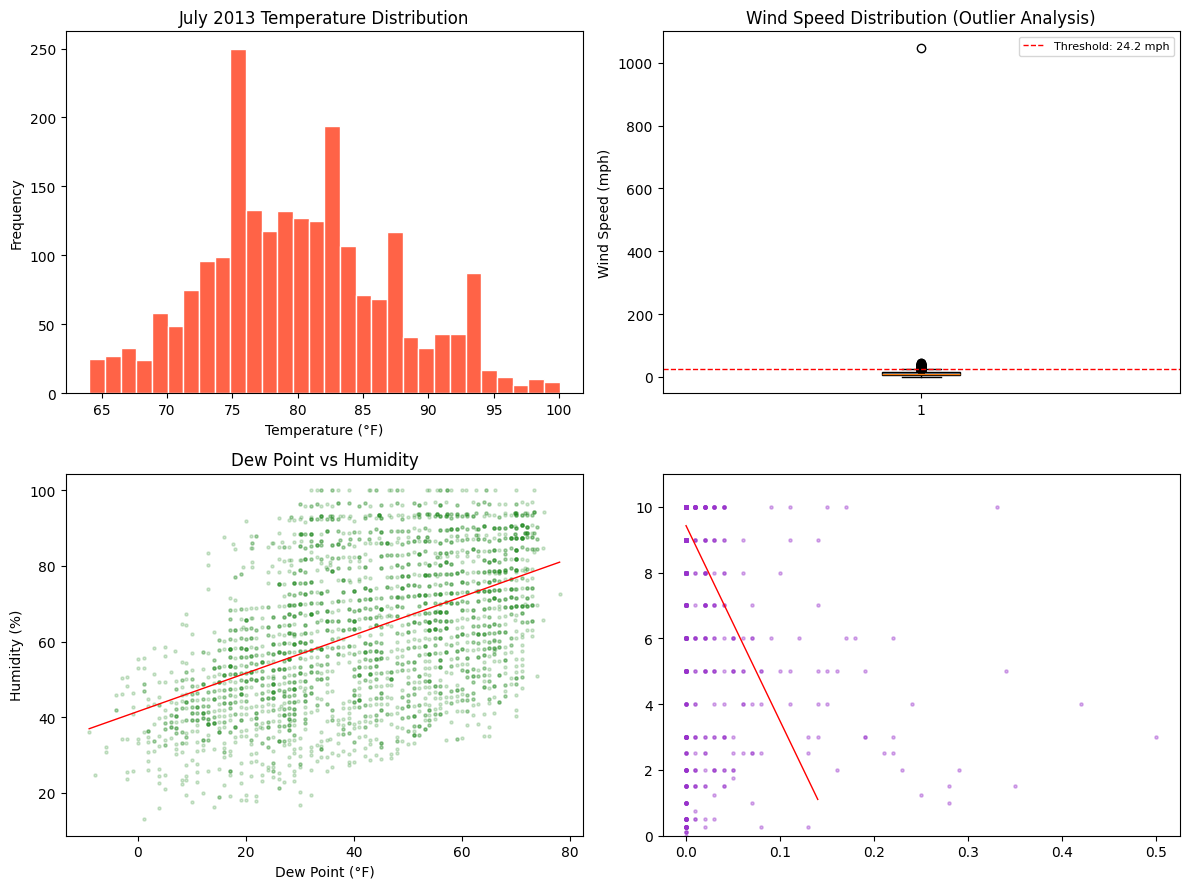


[분석]
- 이슬점(dewp)이 높을수록 습도(humid)가 높아지는 양(+)의 상관관계가 있습니다. (r=0.5122)
- 강수량(precip)이 증가하면 가시거리(visib)는 감소하는 음(-)의 관계를 보입니다. (r=-0.3199)
- wind_speed에서 1048.4mph의 명백한 이상치가 존재합니다. (그 밖의 이상치 415개, 기준: 24.2mph)


In [20]:
# (e) 기상 데이터 분석

july_weather = weather[weather['month'] == 7]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) 7월 기온 히스토그램
axes[0, 0].hist(july_weather['temp'].dropna(), bins=30, color='tomato', edgecolor='white')
axes[0, 0].set_title('July 2013 Temperature Distribution')
axes[0, 0].set_xlabel('Temperature (°F)')
axes[0, 0].set_ylabel('Frequency')

# 2) wind_speed 박스플롯 (이상치 확인)
q25 = weather['wind_speed'].quantile(0.25)
q75 = weather['wind_speed'].quantile(0.75)
iqr = q75 - q25
threshold = q75 + 1.5 * iqr
outliers = weather[weather['wind_speed'] > threshold]['wind_speed']

axes[0, 1].boxplot(weather['wind_speed'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue'))
axes[0, 1].axhline(y=threshold, color='red', linestyle='--', linewidth=1,
                   label=f'Threshold: {threshold:.1f} mph')
axes[0, 1].set_title('Wind Speed Distribution (Outlier Analysis)')
axes[0, 1].set_ylabel('Wind Speed (mph)')
axes[0, 1].legend(fontsize=8)

print(f"wind_speed IQR 기반 이상치 수: {len(outliers)}")
print(f"최대 이상치 값: {outliers.max():.2f} mph")

# 3) dewp vs humid 산점도 + 추세선
sample = weather.sample(n=min(3000, len(weather)), random_state=30)
axes[1, 0].scatter(sample['dewp'], sample['humid'], alpha=0.2, s=5, color='forestgreen')

dewp_clean = sample.dropna(subset=['dewp', 'humid'])
z_dh = np.polyfit(dewp_clean['dewp'], dewp_clean['humid'], 1)
p_dh = np.poly1d(z_dh)
x_dh = np.linspace(dewp_clean['dewp'].min(), dewp_clean['dewp'].max(), 100)
axes[1, 0].plot(x_dh, p_dh(x_dh), color='red', linewidth=1)
axes[1, 0].set_title('Dew Point vs Humidity')
axes[1, 0].set_xlabel('Dew Point (°F)')
axes[1, 0].set_ylabel('Humidity (%)')

# 4) precip vs visib 산점도 + 추세선
axes[1, 1].scatter(sample['precip'], sample['visib'], alpha=0.2, s=5, color='darkorchid')

pv_clean = sample.dropna(subset=['precip', 'visib'])

# precip 이상치 제거 후 추세선 (99th percentile 초과 제외)
pv_trim = pv_clean[pv_clean['precip'] <= pv_clean['precip'].quantile(0.99)]

axes[1, 1].scatter(sample['precip'], sample['visib'], alpha=0.2, s=5, color='darkorchid')

z_pv = np.polyfit(pv_trim['precip'], pv_trim['visib'], 1)
p_pv = np.poly1d(z_pv)
x_pv = np.linspace(pv_trim['precip'].min(), pv_trim['precip'].max(), 100)
axes[1, 1].plot(x_pv, p_pv(x_pv), color='red', linewidth=1)

# y축 범위 고정 (음수 방지)
axes[1, 1].set_ylim(0, 11)
plt.tight_layout()
plt.show()

# 상관계수 출력
corr_dh = weather[['dewp', 'humid']].corr().iloc[0, 1]
corr_pv = weather[['precip', 'visib']].corr().iloc[0, 1]

print("\n[분석]")
print(f"- 이슬점(dewp)이 높을수록 습도(humid)가 높아지는 양(+)의 상관관계가 있습니다. (r={corr_dh:.4f})")
print(f"- 강수량(precip)이 증가하면 가시거리(visib)는 감소하는 음(-)의 관계를 보입니다. (r={corr_pv:.4f})")
print(f"- wind_speed에서 {outliers.max():.1f}mph의 명백한 이상치가 존재합니다. (그 밖의 이상치 {len(outliers)}개, 기준: {threshold:.1f}mph)")

(f) 2013년 뉴욕 지역에서 강수(`precip`)가 발생한 날은 몇 일인지 확인하라. 요일 및 월별 평균 가시거리(`visib`)에 차이가 있었는가? (7점)

2013년 강수 발생 일수: 141일


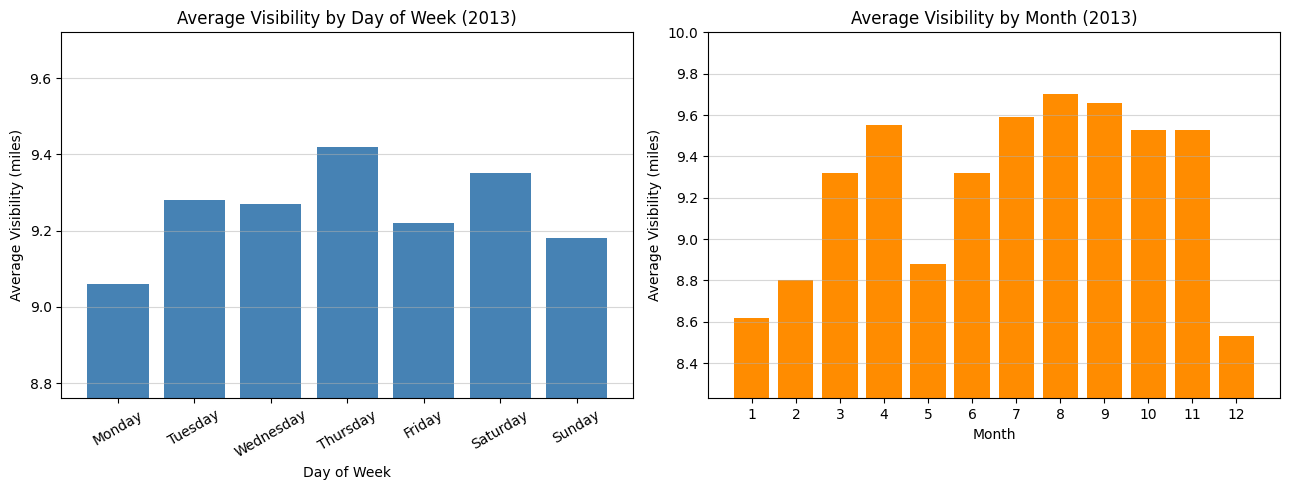


요일별 평균 가시거리 : visib_by_dow

월별 평균 가시거리 : visib_by_month

[분석]
요일별 가시거리 범위: 9.06 ~ 9.42miles — 요일 간 차이 미미
월별 가시거리 범위: 8.53 ~ 9.70miles — 12월 최저, 8월 최고
요일별 가시거리는 큰 차이가 없어 계절·날씨 외의 요인(요일)은 가시거리에 큰 영향을 미치지 않습니다.
월별로는 봄(3~4월)과 초겨울(11~12월)에 가시거리가 다소 낮은 경향을 보입니다.


In [21]:
# (f) 강수 발생 일수 및 가시거리 분석
weather['date'] = pd.to_datetime(weather[['year', 'month', 'day']])
daily_precip = weather.groupby('date')['precip'].sum()
rainy_days = (daily_precip > 0).sum()
print(f"2013년 강수 발생 일수: {rainy_days}일")

# 요일별 평균 가시거리
weather['dayofweek'] = weather['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
visib_by_dow = weather.groupby('dayofweek')['visib'].mean().reindex(dow_order).round(2)

# 월별 평균 가시거리
visib_by_month = weather.groupby('month')['visib'].mean().round(2)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 요일별 — y축 데이터 기반 자동 설정
margin = 0.3
axes[0].bar(dow_order, visib_by_dow.values, color='steelblue')
axes[0].set_title('Average Visibility by Day of Week (2013)')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Visibility (miles)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(visib_by_dow.min() - margin, visib_by_dow.max() + margin)
axes[0].grid(axis='y', alpha=0.5)

# 월별 — y축 데이터 기반 자동 설정
axes[1].bar(visib_by_month.index, visib_by_month.values, color='darkorange')
axes[1].set_title('Average Visibility by Month (2013)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Visibility (miles)')
axes[1].set_xticks(range(1, 13))
axes[1].set_ylim(visib_by_month.min() - margin, visib_by_month.max() + margin)
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n요일별 평균 가시거리 : visib_by_dow")
print(f"\n월별 평균 가시거리 : visib_by_month")
print("\n[분석]")
print(f"요일별 가시거리 범위: {visib_by_dow.min():.2f} ~ {visib_by_dow.max():.2f}miles — 요일 간 차이 미미")
print(f"월별 가시거리 범위: {visib_by_month.min():.2f} ~ {visib_by_month.max():.2f}miles — {visib_by_month.idxmin()}월 최저, {visib_by_month.idxmax()}월 최고")
print("요일별 가시거리는 큰 차이가 없어 계절·날씨 외의 요인(요일)은 가시거리에 큰 영향을 미치지 않습니다.")
print("월별로는 봄(3~4월)과 초겨울(11~12월)에 가시거리가 다소 낮은 경향을 보입니다.")